<a href="https://colab.research.google.com/github/Igor-Luciano-Lacava/dashboard-carreiras-area-dados/blob/main/tratamento-de-dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1 Imersão Dev - Dados com Pandas

In [797]:
import pandas as pd

In [798]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv") #nome da base no nosso arquivo python é df (dataframe). Ele vai ler uma base de dados usando pandas, e o link de onde está. csv pois o link tem um arquivo csv
#BASE DE DADOS DO KAGGLE

In [799]:
df.head(10)#pra ler a base: nome da base, um ponto e o comando da nossa biblioteca, que é head e os parenteses assim () que é pra ler as 5 primeiras linhas da base. Se colocarmos um valor dentro do (), tipo (10), ele le essa quantidade de linhas

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
5,2025.0,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M
6,2025.0,SE,FT,Data Scientist,185000,USD,185000,US,0,US,M
7,2025.0,SE,FT,Data Scientist,148000,USD,148000,US,0,US,M
8,2025.0,MI,FT,Data Scientist,135000,USD,135000,CA,0,CA,M
9,2025.0,MI,FT,Data Scientist,108000,USD,108000,CA,0,CA,M


In [800]:
df.info() #comando para entendermos informações gerais da nossa base de dados. O Dtype é o tipo do dado

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [801]:
df.describe() #detalhes mais aprofundados sobre a base de dados. Só trouxe as colunas numéricas, ou seja, o que é float e int. o count mostra quantas informações temos naquela coluna. a linha max na coluna salary, por exemplo, mostra o maior salario que alguem recebeu naquele ano. min é minimo e mean é media. Dá pra fazer isso com tudo com texto tb

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [802]:
df.shape #tamanho da base. Sem parenteses pois é um atributo, não uma função. o primeiro é linhas e o outro é coluna. Importante pra fazer conta nessa matriz

(133349, 11)

In [803]:
linhas, colunas = df.shape[0], df.shape[1] #vamos dar um print nisso pra ficar mais bonito igual relatorio. criei variaveis linhas e colunas e buscamos onde tao as infos que atribuiremos as variaveis. como a primeira info em python começa com 0, colocamos 0 pra linhas e a segunda, de colunas, é 1.

In [804]:
print("linhas:", linhas, "\n\ncolunas:", colunas)

linhas: 133349 

colunas: 11


In [805]:
df.columns #vamos ver os nomes das colunas


Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [806]:
renomear_colunas = {
    'work_year': 'ano', #aqui estamos atribuindo o novo nome de cada coluna ao pt-br
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
    #se eu quiser mudar de novo. Preciso colocar o nome das colunas da ultima mudança que fiz e colocar na frente o nome novo, igual fizemos na primeira vez
}

df.rename(columns=renomear_colunas, inplace=True) #renomeando df. columns serão agora as palavras novas que redefinimos. inplace é para a substituição ser feita nesse próprio dataframe. Tem como substituir para um novo arquivo para nao perder o original
df.columns



Index(['ano', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda', 'usd',
       'residencia', 'remoto', 'empresa', 'tamanho_empresa'],
      dtype='object')

In [807]:
df["senioridade"].value_counts()

 #colchetes e aspas to acessando uma coluna especifica. Aqui, estamos analisando categorias, ou seja, textos. Estamos vendo quantas pessoas temos de cada nivel de experiencia nesta coluna
 #value_counts conta os valores de cada categoria. SE = SENIOR; MI = MID/INTERMEDIARIO/PLENO; EN = ENTRY/JUNIOR; EX = EXECUTIVO/LÍDER

,count
senioridade,
SE,77241
MI,40465
EN,12443
EX,3200


In [808]:
df["contrato"].value_counts() #mesma coisa com outra variável
#FT = FULLTIME/INTEGRAL ; CT = CONTRATO TEMPORARIO; PT = PART TIME ; FL = FREELANCE

,count
contrato,
FT,132563
CT,394
PT,376
FL,16


In [809]:
df["remoto"].value_counts() #ANALISANDO OUTRA COLUNA
#onde pegamos a base de dados, no kaggle, explica: 0 = trabalhos presenciais, 100 = remoto, 50 = híbridas

,count
remoto,
0,105312
100,27718
50,319


In [810]:
df["tamanho_empresa"].value_counts() #ANALISANDO OUTRA COLUNA
#M= medium; L = large; S = Small

,count
tamanho_empresa,
M,129561
L,3574
S,214


In [811]:
#vamos mudar as categorias de cada coluna. Se um leigo ver "M", "L" e "S", não entende nada. Mesmo processo das colunas
senioridade = { #posso nomear do mesmo nome anterior
    'SE': 'senior',
    'MI': 'pleno',
    'EN': 'junior',
    'EX': 'executivo'
}

df['senioridade'] = df['senioridade'].replace(senioridade) #diferentes formas podem resolver. a função ".map" no lugar de ".replace" faz bem tb
df['senioridade'].value_counts()

,count
senioridade,
senior,77241
pleno,40465
junior,12443
executivo,3200


In [812]:
contrato = { #mudando categorias de outra coluna
    'FT': 'integral',
    'CT': 'contrato',
    'PT': 'parcial',
    'FL': 'freelancer'
}

df['contrato'] = df['contrato'].replace(contrato)
df['contrato'].value_counts()

,count
contrato,
integral,132563
contrato,394
parcial,376
freelancer,16


In [813]:
tamanho_empresa = {
    'M': 'media',
    'L': 'grande',
    'S': 'pequena'
}

df['tamanho_empresa'] = df['tamanho_empresa'].replace(tamanho_empresa)
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
media,129561
grande,3574
pequena,214


In [814]:
remoto = {
    0: 'presencial',
    50: 'hibrido',
    100: 'remoto'
}

df['remoto'] = df['remoto'].replace(remoto)
df['remoto'].value_counts()

,count
remoto,
Presencial,105312
Remoto,27718
Híbrido,319


In [815]:
df.head() #vamo ver como tá nosso df

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,media
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,media
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,media
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,media
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,Presencial,US,media


In [816]:
df.describe(include="object") #agora vamo dar um describe e analisar a categoria e fazer uma analise
#unique são valores unicos de cada categoria: ex --> o senioridade tem senior, pleno, junior e executivo, e por isso tem 4 valores únicos
#linha "top" é qual informação é mais frequente daquela coluna e o "freq" mostra quantas vezes o valor "top", ou seja, o mais frequente, se repetiu

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,senior,integral,Data Scientist,USD,US,Presencial,US,media
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [817]:
df.describe() #pra relembrarmos as nossas variáveis numéricas

,ano,salario,usd
count,133339.000000,1.333490e+05,133349.000000
mean,2024.358770,1.632833e+05,157617.272098
std,0.680627,2.173860e+05,74288.363097
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060200e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


# Aula 2 - Aprenda a Limpar e Preparar Dados

In [818]:
df.isnull() #pra ver se tem infos que tao ausentes, ou que tao nulas, nao preenchidas com algo
#onde não tem dado nulo = false
#onde tive dado nulo = true

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [819]:
df.isnull().sum() #pra identificar somente os dados nulos
#tds linhas de tds variaveis com valor 0, xceto o ano
#sum = ele somou td que era nulo e encontrou 10 campos que não tinham o valor ano

,0
ano,10
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [820]:
df['ano'].unique() #vai trazer quais sao os valores unicos dentro dessa coluna especifica
#nan = not a number = valor nulo

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [821]:
df[df.isnull().any(axis=1)]
#sintaxe é sempre essa, coloco nome da base e o filtro/função depois
#aqui tô fazendo um filtro de tudo que é nulo dentro da base chamando o [df.isnull()]
#o filtro .any(axis=1) é que queremos só exibir a dimensão das nulas. Axis = dimensão
#tradução: me traga tudo da base que o isnull é True (ou seja, valores nulos), e imprima isso pra mim

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
5588,NaN,senior,integral,Product Manager,184500,USD,184500,US,Presencial,US,media
59692,NaN,pleno,integral,Engineer,110000,USD,110000,DE,Presencial,DE,media
59710,NaN,junior,integral,Data Scientist,208800,USD,208800,US,Presencial,US,media
59759,NaN,senior,integral,Software Engineer,135000,USD,135000,US,Presencial,US,media
59789,NaN,senior,integral,Engineer,112000,USD,112000,US,Presencial,US,media
131000,NaN,senior,integral,Machine Learning Engineer,163800,USD,163800,US,Presencial,US,media
131006,NaN,senior,integral,Data Analytics Manager,204500,USD,204500,US,Presencial,US,media
133054,NaN,junior,integral,Data Scientist,40000,USD,40000,JP,Remoto,MY,grande
133281,NaN,pleno,integral,Machine Learning Engineer,180000,PLN,46597,PL,Remoto,PL,grande
133317,NaN,pleno,integral,Data Scientist,130000,USD,130000,US,Híbrido,US,grande


In [822]:
#posso colocar info na df, quando nao tem
#posso excluir dados que não tem info, pra nao ficar lixo na base
#posso fazer imputação com regras mais inteligentes ou mais simples
#exemplo: alguns campos nao tem salario. pra nao alterar a media final, podemos preencher com o valor medio dos salarios ou até a mediana, não descalibra a base
#vamos criar um df pequeno ficticio pra estudo disso
import numpy as np #biblioteca de numeros do python, para conseguirmos colocar nulo no salário do bruno
df_salarios = pd.DataFrame({ #criando um dataframe nomeado salarios. Temos de chamar o Pandas e colocar esse comando
  'nome': ['Ana', 'Bruno', 'Carlos', 'Daniele', "Val"],
  'salario': [4000, np.nan, 5000, np.nan, 100000]    #variavel numéria não precisa de aspas, só o numero msm; np.nan é o nulo importado da biblio numpy
    #criamos duas colunas, nome e salario, e colocamos os elementos dentro dela
})

#tudo que for nulo, estamos preenchendo com a média do valor. aqui, calcularemos a média
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))  #"df_salarios['salario_media'] =" estamos criando dentro da base df_salarios outra coluna da media de salario chamada 'salario_media que conterao as medias, entao o igual é que ela recebe aquele valor a frente que estamos calculando
#fillna é preencher os valores nulos dessa base de dados 'df_salarios' na coluna salarios com o valor que será calculado
#(df_salarios['salario'].mean().round(2)) = mean é media, e round 2 é que arrendondamos para duas casas decimais. esse é o calculo que pegamos os valores 'salarios' na base "df_salarios" e fazemos a media e arrendondamos para duas casas decimais

df_salarios['salario_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median()) #aqui é pra mediana

df_salarios #pra printar
#media de 5000 e 4000 é 4500, e preencheram com a media no daniele e bruno que o salario tá nulo

#a Val foi adicionada pra teste. Como ganha salario acima de todo mundo, a media do salario do bruno e daniele ficam altos, mas pode nao ser realidade, pq a Val destoou. Agora, a mediana suave esse impacto do salario da Val que não é padrao do mercado

,nome,salario,salario_media,salario_mediana
0,Ana,4000.0,4000.00,4000.0
1,Bruno,NaN,36333.33,5000.0
2,Carlos,5000.0,5000.00,5000.0
3,Daniele,NaN,36333.33,5000.0
4,Val,100000.0,100000.00,100000.0


In [823]:
df_temperatura = pd.DataFrame ({ #vamos fazer a msm coisa com temperatura
    'Dia': ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    'Temperatura': [30, np.nan, np.nan, 28, 27]
    })

df_temperatura["preenchido_ffill"] = df_temperatura["Temperatura"].ffill() #nova coluna para comparar como ficar antes e depois do preenchimento
df_temperatura
#ffill = forward fill = completa a lacuna com o valor anterior. por isso terça e quarta ficaram com 30, que era de segunda feira

,Dia,Temperatura,preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,30.0
2,Quarta,NaN,30.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [824]:
df_temperatura = pd.DataFrame ({ #vamos fazer a msm coisa com temperatura
    'Dia': ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    'Temperatura': [30, np.nan, np.nan, 28, 27]
    })

df_temperatura["preenchido_bfill"] = df_temperatura["Temperatura"].bfill() #nova coluna para comparar como ficar antes e depois do preenchimento
df_temperatura
#ffill = back fill = completa a lacuna com o valor posterior. por isso terça e quarta ficaram com 28, que era de quinta feira. Isso é pra se acaso segunda também estivesse com o valor nulo. Aí nao teria valor na segunda pro terça e quarta puxar


,Dia,Temperatura,preenchido_bfill
0,Segunda,30.0,30.0
1,Terça,NaN,28.0
2,Quarta,NaN,28.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [825]:
df_cidades = pd.DataFrame({ #aqui, faremos assim: algumas pessoas nao terao salarios, mas ao inves de ficar nulo, vamos colocar que não foi definido
    #df_cidades = pd.DataFrame estamos criando um dataframe. Estamos chamando uma função, de criar o data frame, por isso abrimos parenteses.
    #na criação de nomes ou listas, usamos chaves
    'nome': ['Ana', 'Bruno', 'Carlos', 'Daniele', "Val"],
    'cidade': ['São Paulo', np.nan, "Curitiba", np.nan, "Belém"]
})
df_cidades["cidade_preenchida"] = df_cidades["cidade"].fillna("Não informado")
df_cidades #pode colocar display(df_cidades), que ele também printa
 #nova coluna com esse novo valor que vamos apresentar
 #dentro do parenteses do fillna colocamos o que queremos que substitua os valores nulos

#se é um método que chamamos, é parenteses
#criando um dataframe ou base de dados nova, vai ser chaves
#acessando uma coluna especifica do banco, usamos colchete

,nome,cidade,cidade_preenchida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Daniele,NaN,Não informado
4,Val,Belém,Belém


In [826]:
#no caso do ano, em que tivemos 10 pessoas com ano nulo, o que faremos pra tratar os dados? Média e mediana não é interessante no caso do ano, Não informado é bom. Mas melhor alternativa é só descartar essas 10 pessoas. são 130.000 pessoas, 10 não fará diferença. Excluir não vai penalizar e nao corre o risco de colocar informação equivocada
#não use esse método de exclusao diretamente no df que estamos trabalhando. Porque vamos sobrescrever e vamos perder antes de ter tratado os dados
df_limpo = df.dropna() #aqui criando o novo
df_limpo.isnull().sum() #vendo se dá certo. A soma vai mostrar que o nosso novo df_limpo não tem os 10 nulos igual a nossa df original. Essa nova tem dados limnpos

#se dermos df_limpo.info(), vemos que a variavel ano ta em float, então aparecerá 2025.0 quando dermos df_limpo.head.
#Vamos converter o ano em inteiro então.


,0
ano,0
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [827]:
df_limpo = df_limpo.assign(ano = df_limpo['ano'].astype("int64")) #assign to definindo.
#df_limpo vai receber (igual) o df_limpo de novo que vai ser reconfigurado (assign), e vamos mudar toda coluna ano_trabalho, e a coluna ano vai receber toda coluna ano_trabalho anterior só que com um novo tipo, sendo int.

df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ano              133339 non-null  int64 
 1   senioridade      133339 non-null  object
 2   contrato         133339 non-null  object
 3   cargo            133339 non-null  object
 4   salario          133339 non-null  int64 
 5   moeda            133339 non-null  object
 6   usd              133339 non-null  int64 
 7   residencia       133339 non-null  object
 8   remoto           133339 non-null  object
 9   empresa          133339 non-null  object
 10  tamanho_empresa  133339 non-null  object
dtypes: int64(3), object(8)
memory usage: 12.2+ MB


# Aula 3 - Crie Gráficos e Conte Histórias com Dados

In [828]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,media
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,media
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,media
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,media
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,Presencial,US,media


<Axes: title={'center': 'Distribuição dos Níveis de Experiência'}, xlabel='senioridade'>

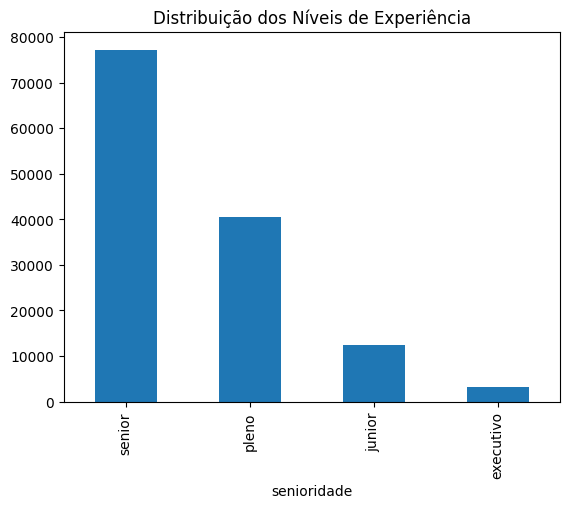

In [829]:
#VAMOS CRIAR UM GRÁFICO COM A PRÓPRIA BIBLIOTECA PANDAS, QUE FAZ ESSA FUNÇÃO
#vamos contar em gráfico a quantidade de cada categoria que temos na coluna senioridade
df_limpo['senioridade'].value_counts().plot(kind='bar', title="Distribuição dos Níveis de Experiência") #aqui com o colchetes estamos chamando a coluna senioridade da nossa base de dados "df_limpo", onde os dados já estão tratados
#value_counts conta a quantidade de cada valor, ou seja, a frequencia. ".plot" é pra plotar o gráfico. "(kind='bar'" é o tipo de gráfico que queremos, que é por barra
#title="Distribuição dos Níveis de Experiência" é o título que queremos dar ao nosso gráfico

<Axes: xlabel='senioridade', ylabel='usd'>

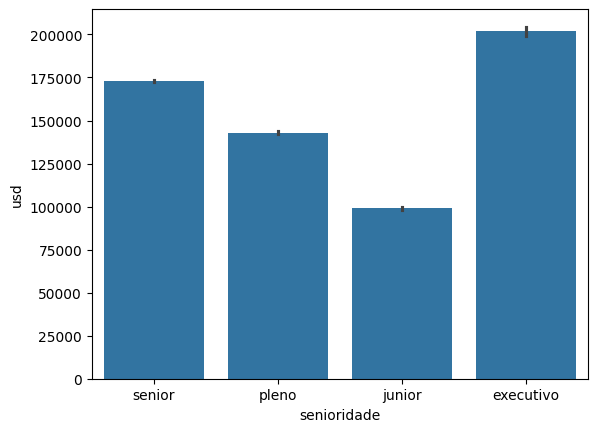

In [830]:
#pra adicionar mais recursos e ferramentas em nossos gráficos, temos duas bibliotecas chamadas "Matplotlib" e "Seaborn" que são voltadas para isso mesmo. A Pandas é muito limitada
#kaggle é um lugar interessante de aprendizado também.
import seaborn as sns #essa biblio abre muito o leque de estatisticas, com desviao padrao no grafico e etc
#vamos calcular quanto cada categoria da coluna de senioridade está ganhando de salário em média
sns.barplot(data=df_limpo, x='senioridade', y='usd') #sns.barplot = chamei a biblio e dei a função dele criar um gráfico em barras
#define parametro, ou seja, quem são os nossos dados, que puxamos da nossa outra base de dados df_limpo
#x='senioridade' estamos definindo que o nosso eixo x será do senioridade, igual ao grafico anterior, onde o senior, intermed, junnior e exec estão no eixo horizontal
#y='usd' estamos definindo que o nosso eixo y será do em_usd, pois se pegarmos somente a coluna salario, pode estar em diferentes moedas. Pra padronizar, pega ja a coluna do salario em usd
#vamos deixar mais bonito, colocar um titulo pro grafico geral, e nao deixae "usd" e "senioridade" como títulos. Vamos personalizar com a matplotlib. ela é usada como base pro pandas e seaborn. Google collab tb ja tem ela instalada


In [831]:
import matplotlib.pyplot as plt #estamos usando um modulo especifico da matplotlib chamado pyplot

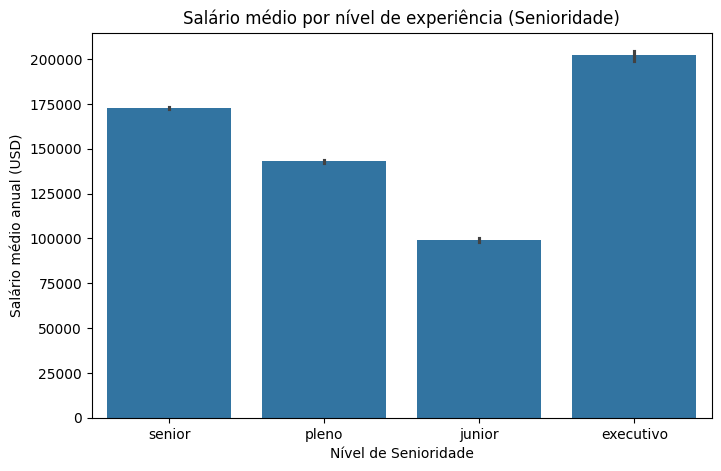

In [832]:
#vamos definir tamanho da imagem
plt.figure(figsize=(8,5)) #plt.figure é que vamos definir a figura que vai ser passado com os parametros que estao dentro dos parenteses
#figsize define o tamanho, que colocamos 8,5
#agora vamos definir o que queremos na figura com aquela linha que fizemos com o seaborn
sns.barplot(data=df_limpo, x='senioridade', y='usd')
#agora vamos personalizá-la, com infos que deixem a visualização mais intuitiva
plt.title('Salário médio por nível de experiência (Senioridade)') #aqui é o título geral do gráfico
plt.xlabel("Nível de Senioridade")#aqui damos nome ao nosso eixo x, rotulando ele
plt.ylabel("Salário médio anual (USD)") #aqui damos nome ao nosso eixo y, rotulando ele
plt.show() #pra printar imagem sem aquele texto em cima do gráfico que ficou igual no nosso gráfico anterior

In [833]:
#vamos ordenar agora as barras do maior para o menor valor, usando um método da biblio Pandas que faz agrupamentos e ordenações
df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False) #df_limpo.groupby('senioridade') é qual coluna ele use para agrupar
#['usd'].mean() é qual coluna que queremos que calcule alguma estatistica, que nesse caso é a media da coluna usd
#sort_values é o método pra ele ordenar os valores obtidos das medias. (ascending=False) é pra ser do maior pro menor valor. Pra ser do menor pro maior, coloca True ao invés de False

,usd
senioridade,
executivo,202027.667813
senior,172850.838301
pleno,143044.845979
junior,99034.963267


In [834]:
#vamos passar tudo isso para dentro de uma variável para passar como parâmetro para o seaborn conseguir fazer a ordenação
#variavel é para armazenarmos uma informação lá dentro pra que depois possamos usar de maneira mais fácil, sem precisar ficar repetindo todo o código novamente
ordem = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).index #ordem é o nome da variável e index é o comando para salvar nessa variável, e colocar as linhas do nosso gráfico anterior, que estão em ordem do maior pro menor, em uma lista com a mesma ordem
ordem

Index(['executivo', 'senior', 'pleno', 'junior'], dtype='object', name='senioridade')

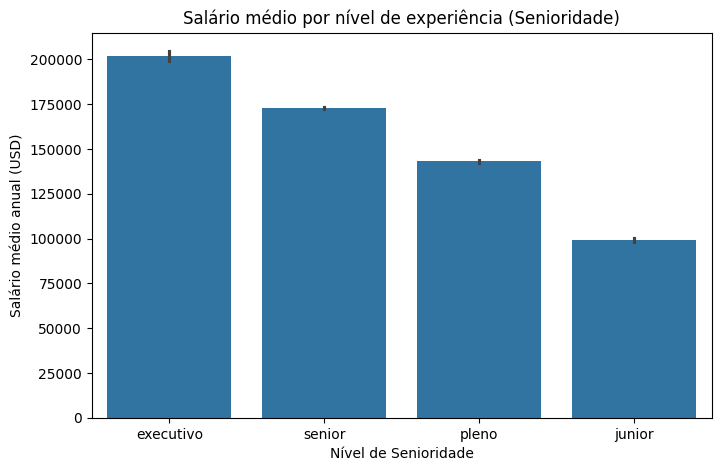

In [835]:
#vamos passar isso pra dentro do código do nosso gráfico
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x='senioridade', y='usd', order=ordem) #adicionamos novo parametro order, que é igual a ordem que fizemos no código anterior
plt.title('Salário médio por nível de experiência (Senioridade)')
plt.xlabel("Nível de Senioridade")
plt.ylabel("Salário médio anual (USD)")
plt.show()

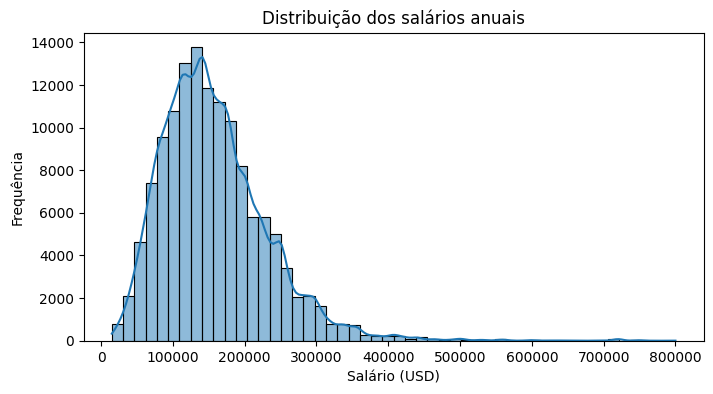

In [836]:
#vamos usar outra variavel e testar outro tipo de grafico. Bora ver a distribuição salarial com histograma
plt.figure(figsize=(8,4)) #primeiro numero é largura e o segundo é altura
sns.histplot(df_limpo['usd'], bins = 50, kde=True ) #histplot = histograma, dentro do parenteses colocamos qual coluna queremos analisar com o df_limpo['usd']
#bins Os valores tão indo de 50 a 50. É a largura das barras que tao aparecendo
#kde é um parametro, mais especificamente é uma linha que vai ser adicionada no gráfico pra ficar mais facil de visualizar
#agora vamos colocar titulos e labels
plt.title('Distribuição dos salários anuais')
plt.xlabel("Salário (USD)")
plt.ylabel("Frequência")
plt.show()


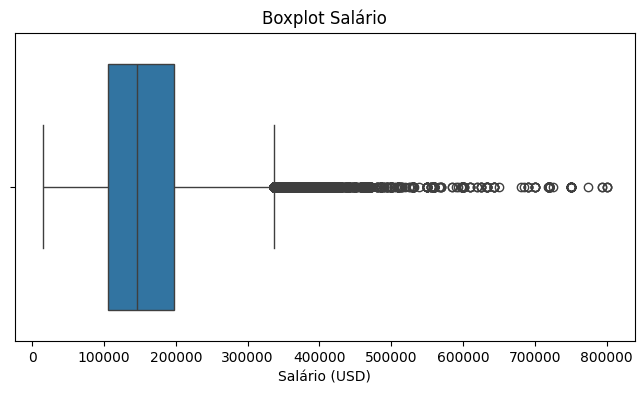

In [837]:
#distribuição tá feia. Valores tão concentrados na esquerda. O pico tem de estar exatamente no meio dessa distruibuição
#Agora, vamos ver boxplot, que permite ver dados mais estatistica e detalhadamente
plt.figure(figsize=(8,4))
sns.boxplot(x=df_limpo['usd'])
plt.title('Boxplot Salário')
plt.xlabel("Salário (USD)")
plt.show()
#extremidades da caixa mostram valor minimo e maximo, mostrando a variância
#linha no meio da caixa é a mediana, que tá entre 100k e 200k
#tem os quartis de 25 e 75%
#esses pontos são outliars, que sao dados discrepantes, fora desse intervalo visualizado. São a mesma coisa que a parte direita do histograma acima, onde tem as exceçoes com as barras minusculas na parte do 500k a 800k
#consigo ver, por exemplo, no mundo dos negocios. Quero contratar datascientist dos melhores. Vemos que a media é 150k. Se ofereecer salario igual ou abaixo. Talvez nao consiga captar esses profissionais bons. Mas temos um limite ali, conseguimos ver o valor que nao sai muito do padrão, que são os outliars.
#Conseguimos ver por nível de xp tb, pelos cargos, etc

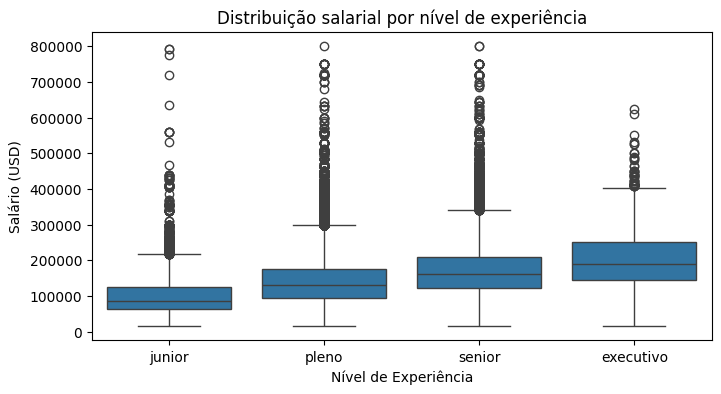

In [838]:
#vamos ver pelo nivel de experiencia agr
#antes vamo criar uma variavel, para criar uma ordem que queremos, pois temos varias variaveis nesse codigo
ordem_nivelxp = ['junior', 'pleno', 'senior', 'executivo']
plt.figure(figsize=(8,4))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_nivelxp) #data=df_limpo estamos definindo os dados que serão capturados
plt.title('Distribuição salarial por nível de experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário (USD)')
plt.show()
#uma caixa pra cada nivel, mediana do executivo e senior é alta. Pode ser usado pra saber quais niveis precisam de contratações novas
#tem outliars de senior que ganham mais que os executivos, pois principalmente em datasciente tem algumas pessoas técnicas que são referências globais, e acabam ganhando mais que os executivos
#alguns juniors ganhando mt, não deveriam ser seniors? é assim que analista de dados trabalham


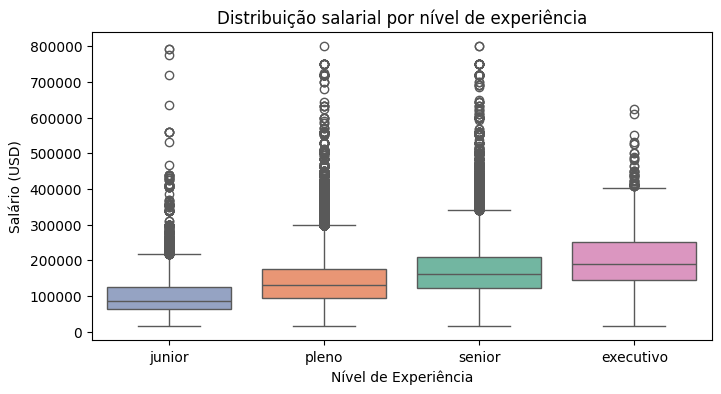

In [839]:
#vamos mudar cor
ordem_nivelxp = ['junior', 'pleno', 'senior', 'executivo']
plt.figure(figsize=(8,4))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_nivelxp, palette='Set2', hue='senioridade') #palette é pra mudar cor. Set2 é pra variável categórica, então teremos uma cor diferente para cada categoria. hue é parametro que define uma cor para cada categoria da variável que a gente especificar para ele. nesse caso é a senioridade, o nivel de experiencia
plt.title('Distribuição salarial por nível de experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário (USD)')
plt.show()

In [840]:
#vamos criar um gráfico interativo, não mais estático
#biblioteca plotly permite isso
import plotly.express as px #usando modulo express da plotly, apelidado de px

In [841]:
senioridade_media_salario = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).reset_index() #sort_values para ordenar os valores. reset_index: cada coluna é indexada, vai ter um valor. o reset tira os valores da primeira coluna que temos e colocar só os nomes, que no nosso caso é a coluna senioridade
fig = px.bar(senioridade_media_salario,
             x='senioridade',
             y='usd',
             title='Media Salarial por Senioridade',
             labels={'senioridade': "Nivel Senioridade", 'usd': 'Média Salarial Anual (USD)'}) #label do x e y, só um jeito diferente do que fizemos, que tinhamos colocado o label em cada linha pro x e pro y
fig.show() #ele armazenou tudo numa variavel chamada fig e exibe com o show no final
#passando o mouse em cima, mostra as infos de cada barra
#não conseguiriamos ver com exatidao a media salarial em graficos estaticos, como exemplo, o do senior sendo 172.850k

In [842]:
#vamos fazer um gráfico de pizza. Tem de ter poucas categoria. Pra isso, vamos pegar uma variavel de tres categorias: se é remoto, presencial ou hibrido
#antes temos de verificar a frequencia de cada categoria
remoto_contagem = df_limpo['remoto'].value_counts().reset_index() #value_counts faz a contagem da frequência
remoto_contagem.columns = ['tipo_trabalho', 'quantidade'] #definindo as colunas que participam dessa contagem que tamos fazendo
fig = px.pie(remoto_contagem, #px.pie é grafico de pizza, ou torta, mesmo formato
             names='tipo_trabalho', #não tem x nem y, teremos parametros names
             values='quantidade', #valores de cada tipo de trabalho
             title='Proporção dos tipos de trabalho'
)
fig.show()
             #podemos criar uma pizza ou rosca. Vamo na pizza primeiro. mantém código assim
             #consigo filtrar. Pra tirar algum deles, clica no quadradinho no canto superior direito referente a parcela que voce quer eliminar da rosca


In [843]:

remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(remoto_contagem,
             names='tipo_trabalho',
             values='quantidade',
             title='Proporção dos tipos de trabalho',
             hole=0.5 #parametro que deixa um buraco dentro da pizza
)
fig.show()




In [844]:

remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(remoto_contagem,
             names='tipo_trabalho',
             values='quantidade',
             title='Proporção dos tipos de trabalho',
             hole=0.5
)

fig.update_traces(textinfo='percent+label') #para exibir tanto a porcentagem quanto o label de cada parte que a gente tem da rosquinha
fig.show()




# Aula 4 - Construindo um dashboard interativo

In [845]:
#grafico do desafio do final da aula 3 que eles deixaram, este eles que criaram
#pra criar mapa, o local que as pessoas tao trabalhando, que é nossa coluna "residencia"
#ali, a sigla dos paises tem duas letras. Pra conseguir criar o mapa usando plotly, precisamos converter para 3 letras (ISO3)
#pra fazer conversao, precisamos usar a biblio 'pycountry'.
#as outras biblios aqui no colab só importamos pq ele ja tinha. Essa ele nao tem e precisamos instalar


In [846]:
pip install pycountry

In [847]:
#instalada, agr dá um import e usaremos ela
import pycountry

#Função para converter ISO 2 em ISO 3
def iso2_to_iso3(code): #retornando o codigo em 3 siglas
  try:
    return pycountry.countries.get(alpha_2=code).alpha_3
  except:
    return None

#Criar nova coluna com código ISO-3
df_limpo['residencia_iso3'] = df_limpo['residencia'].apply(iso2_to_iso3) #criando uma nova coluna no nosso dataframe original que tenha essa info das 3 siglas. Pra isso, pegamos nosso df_limpo, pegamos a coluna "residencia", que é a que tem 2 letras, usa função "apply" da biblio pandas e aplica a função iso2_to_iso3 que criamos ali em cima
#nesse caso, dando um head, apareceria as duas colunas, de 2 e 3 letras

#Calcular média salarial por país (Iso3) para cientista de daods
df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist'] #media salarial por pais para o cargo de cientista de dados. Filtragem na variavel df_ds, pegando df_limpo, especificando o cargo do df_limpo sendo data scientist, com dois iguais
media_ds_pais = df_ds.groupby('residencia_iso3')['usd'].mean().reset_index() #agrupando pela residencia com iso3 agora, pegando a media do usd

#Gerar o mapa
fig = px.choropleth(media_ds_pais, #choropleth é o mapa, estilo do mapa, e passamos dados que queremos
                    locations='residencia_iso3',
                    color='usd',
                    color_continuous_scale='rdylgn', #paleta de cores, onde o valor mais alto aparece em verde, intermediario em amarelo e menores em vermelho, ela ta na documentação da plotly
                    title='Salário médio de cientista de dados por país',
                    labels={'usd': 'Salário médio (USD)', 'residencia_iso3': 'País'})
fig.show()
#gráfico pronto, levemos ao nosso dash



In [848]:
#vamos ver como ficou nossa base
df_limpo.head() #nova coluna em redação ao df antigo, que é a residencia_iso3

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,Presencial,US,media,USA


In [849]:
#agora, estamos usando a base no github da val. Mas quero usar minha base. Como salvo isso tudo no meu computador?
df_limpo.to_csv('dados-imersao-final.csv', index=False) #convertendo pra csv, dando nome ao arquivo, index=False é pra ele nao criar um novo index em cima desse arquivo. se não, vamos ter um index a mais além do que já existe, index sao os numeros que temos no canto esquerdo do grafico
#pra baixar, vai no icone de pasta no canto esquerdo do colab, acha o arquivo e vai em download. Pronto. Tá na sua maquina, pode subir pro github dps
#salva na msm pasta dos codigos do vscode
